# 📊 Comprehensive R² Analysis for Fog Prediction Models

**A systematic approach to diagnosing model performance issues**

## 🎯 Key Research Questions

1. **Data Scaling Issue**: Are predictions and ground truth on different scales?
2. **Over-smoothing**: Is the diffusion model removing important spatial features?
3. **Spatial Performance**: Does the model perform well in some regions but poorly in others?
4. **Feature Detection**: Can the model detect localized fog clusters or just large-scale patterns?
5. **Diffusion Parameters**: Are 20 diffusion steps causing excessive smoothing?

## 📋 Analysis Sections

1. **Data Loading & Rescaling Investigation** - Test 5 scaling scenarios
2. **Spatial Performance Analysis** - Regional performance variations
3. **Feature Detection Analysis** - Fog clustering and smoothness
4. **Diffusion Parameters Assessment** - Over/under-smoothing diagnosis
5. **Summary & Recommendations** - Actionable insights

## 🔧 Setup & Configuration

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import json
from scipy import ndimage

# Configuration
netcdf_path = '/app/outputs/generation/Fog_index/20260205_095507/ensemble_Fog_index_20260205_095507.nc'
stats_file = '/app/host/mnt/storage/younes.abid/physicsnemo/data/custom_data_2/stats_432/stat.json'
time_idx = 0  # Updated to time index 0 (better results)
var_name = 'Fog_index'

# Plot settings
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print('🔍 Comprehensive R² Analysis Initialized')
print(f'📁 Data: {netcdf_path.split("/")[-1]}')
print(f'⏰ Time index: {time_idx}')

🔍 Comprehensive R² Analysis Initialized
📁 Data: ensemble_Fog_index_20260205_095507.nc
⏰ Time index: 0


# 1️⃣ Data Loading & Rescaling Investigation

**Goal**: Determine if predictions and ground truth are on compatible scales

In [3]:
# Load normalization statistics
try:
    with open(stats_file, 'r') as f:
        stats = json.load(f)
    fog_stats = stats['output'][var_name]
    fog_mean, fog_std = fog_stats['mean'], fog_stats['std']
    print(f'✅ Loaded normalization stats: μ={fog_mean:.3f}, σ={fog_std:.3f}')
except Exception as e:
    print(f'❌ Stats loading failed: {e}')
    fog_mean, fog_std = 0, 1

# Define scaling functions
normalize = lambda x: (x - fog_mean) / fog_std
denormalize = lambda x: x * fog_std + fog_mean

✅ Loaded normalization stats: μ=66.363, σ=23.212


In [4]:
# Load ensemble predictions and ground truth
with xr.open_dataset(netcdf_path, group='prediction') as ds:
    predictions = ds[var_name].isel(time=time_idx)  # (ensemble, y, x)
    coords_2d = 'lat' in ds.data_vars and 'lon' in ds.data_vars
    if coords_2d:
        lat_2d, lon_2d = ds['lat'].values, ds['lon'].values

with xr.open_dataset(netcdf_path, group='truth') as ds:
    ground_truth = ds[var_name].isel(time=time_idx)  # (y, x)

ensemble_mean = predictions.mean('ensemble')

print(f'📊 Data loaded: {predictions.shape} → {ensemble_mean.shape}')
print(f'🗺️ Coordinates: {"2D geographic" if coords_2d else "Grid indices"}')

📊 Data loaded: (4, 432, 432) → (432, 432)
🗺️ Coordinates: Grid indices


In [5]:
# Test rescaling scenarios
def calculate_metrics(pred, truth, name):
    """Calculate R² and correlation"""
    pred_flat, truth_flat = pred.values.flatten(), truth.values.flatten()
    valid = ~(np.isnan(pred_flat) | np.isnan(truth_flat))
    p, t = pred_flat[valid], truth_flat[valid]
    
    if len(p) > 1:
        corr = np.corrcoef(p, t)[0, 1]
        ss_res, ss_tot = np.sum((t - p)**2), np.sum((t - t.mean())**2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        return {'r2': r2, 'corr': corr, 'pred': p, 'truth': t}
    return None

# Test 5 rescaling scenarios
scenarios = {
    'raw': calculate_metrics(ensemble_mean, ground_truth, 'Raw'),
    'both_norm': calculate_metrics(normalize(ensemble_mean), normalize(ground_truth), 'Both Normalized'),
    'both_denorm': calculate_metrics(denormalize(ensemble_mean), denormalize(ground_truth), 'Both Denormalized'),
    'pred_norm': calculate_metrics(normalize(ensemble_mean), ground_truth, 'Pred Normalized'),
    'truth_norm': calculate_metrics(ensemble_mean, normalize(ground_truth), 'Truth Normalized')
}

# Find best scenario
valid_scenarios = {k: v for k, v in scenarios.items() if v is not None}
best_scenario = max(valid_scenarios.keys(), key=lambda k: valid_scenarios[k]['r2'])
best_r2 = valid_scenarios[best_scenario]['r2']

print('\n🏆 RESCALING RESULTS:')
scenario_names = {'raw': '🔵 Raw', 'both_norm': '🟢 Both Norm', 'both_denorm': '🟡 Both Denorm', 
                 'pred_norm': '🔴 Pred Norm', 'truth_norm': '🟣 Truth Norm'}
for k, v in valid_scenarios.items():
    marker = '🎯' if k == best_scenario else '  '
    print(f'{marker} {scenario_names[k]}: R²={v["r2"]:.4f}, r={v["corr"]:.4f}')

print(f'\n🏆 Best: {scenario_names[best_scenario]} (R²={best_r2:.4f})')


🏆 RESCALING RESULTS:
🎯 🔵 Raw: R²=0.7849, r=0.9188
   🟢 Both Norm: R²=0.7849, r=0.9188
   🟡 Both Denorm: R²=0.7849, r=0.9188
   🔴 Pred Norm: R²=-6.0371, r=0.9188
   🟣 Truth Norm: R²=-3034.2991, r=0.9188

🏆 Best: 🔵 Raw (R²=0.7849)


/tmp/ipykernel_50069/2032908474.py:42: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_50069/2032908474.py:42: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_50069/2032908474.py:42: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.p

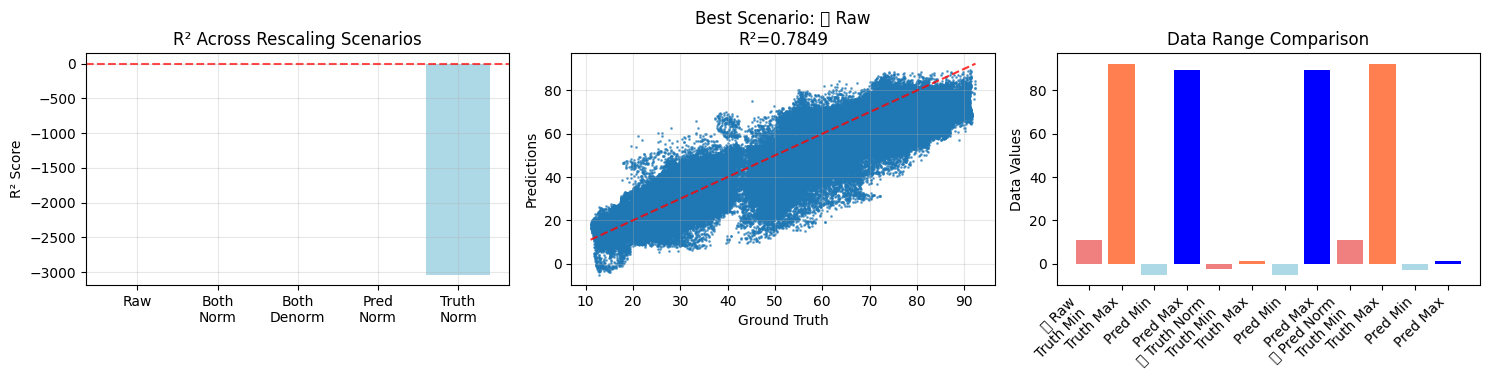

In [6]:
# Visualize rescaling results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bar chart of R² values
r2_vals = [valid_scenarios[k]['r2'] for k in ['raw', 'both_norm', 'both_denorm', 'pred_norm', 'truth_norm']]
colors = ['gold' if i == list(valid_scenarios.keys()).index(best_scenario) else 'lightblue' for i in range(5)]
axes[0].bar(range(5), r2_vals, color=colors)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['Raw', 'Both\nNorm', 'Both\nDenorm', 'Pred\nNorm', 'Truth\nNorm'], rotation=0)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Across Rescaling Scenarios')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.7)

# Scatter plot of best scenario
best_data = valid_scenarios[best_scenario]
axes[1].scatter(best_data['truth'], best_data['pred'], alpha=0.6, s=1)
min_val, max_val = best_data['truth'].min(), max(best_data['truth'].max(), best_data['pred'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
axes[1].set_xlabel('Ground Truth')
axes[1].set_ylabel('Predictions')
axes[1].set_title(f'Best Scenario: {scenario_names[best_scenario]}\nR²={best_r2:.4f}')
axes[1].grid(True, alpha=0.3)

# Data range comparison
ranges = []
labels = []
for k in ['raw', 'truth_norm', 'pred_norm']:
    if k in valid_scenarios:
        data = valid_scenarios[k]
        ranges.extend([data['truth'].min(), data['truth'].max(), data['pred'].min(), data['pred'].max()])
        labels.extend([f'{scenario_names[k]}\nTruth Min', 'Truth Max', 'Pred Min', 'Pred Max'])

if ranges:
    x_pos = np.arange(len(ranges))
    axes[2].bar(x_pos, ranges, color=['lightcoral', 'coral', 'lightblue', 'blue'] * (len(ranges)//4))
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(labels, rotation=45, ha='right')
    axes[2].set_ylabel('Data Values')
    axes[2].set_title('Data Range Comparison')

plt.tight_layout()
plt.show()

# 2️⃣ Spatial Performance Analysis

**Goal**: Identify if model performs well in some regions but poorly in others

In [7]:
# Get best scenario data for spatial analysis
if best_scenario == 'truth_norm':
    spatial_pred, spatial_truth = ensemble_mean, normalize(ground_truth)
elif best_scenario == 'pred_norm':
    spatial_pred, spatial_truth = normalize(ensemble_mean), ground_truth
elif best_scenario == 'both_norm':
    spatial_pred, spatial_truth = normalize(ensemble_mean), normalize(ground_truth)
elif best_scenario == 'both_denorm':
    spatial_pred, spatial_truth = denormalize(ensemble_mean), denormalize(ground_truth)
else:
    spatial_pred, spatial_truth = ensemble_mean, ground_truth

# Calculate spatial error metrics
spatial_error = spatial_pred - spatial_truth
spatial_abs_error = np.abs(spatial_error)
spatial_squared_error = spatial_error ** 2

print(f'🗺️ Spatial Analysis using {scenario_names[best_scenario]} scaling')
print(f'📊 Error statistics:')
print(f'   Mean Error (Bias): {float(spatial_error.mean()):.4f}')
print(f'   Mean Absolute Error: {float(spatial_abs_error.mean()):.4f}')
print(f'   RMSE: {float(np.sqrt(spatial_squared_error.mean())):.4f}')

🗺️ Spatial Analysis using 🔵 Raw scaling
📊 Error statistics:
   Mean Error (Bias): -5.4668
   Mean Absolute Error: 8.4415
   RMSE: 10.5715


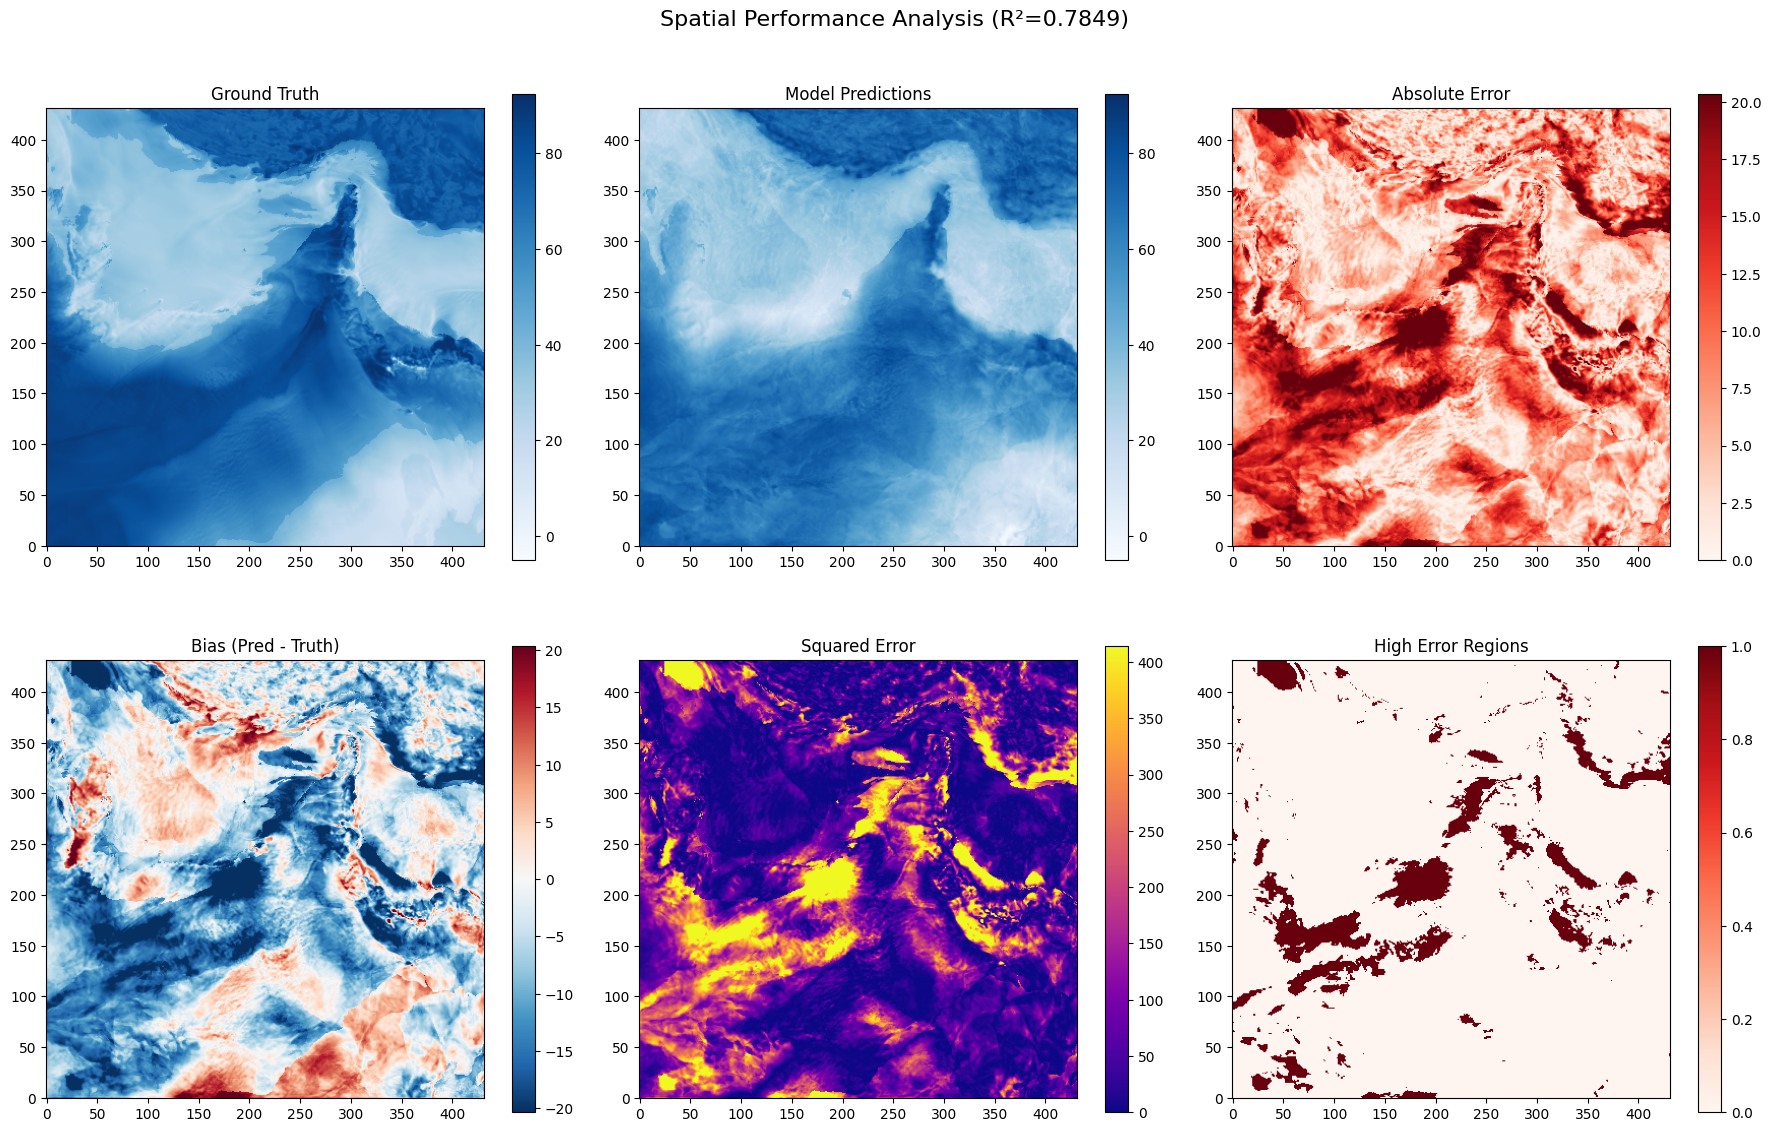

In [8]:
# Create spatial visualization using cartopy
if coords_2d:
    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': proj})
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Define common colormap range
vmin, vmax = min(spatial_pred.min(), spatial_truth.min()), max(spatial_pred.max(), spatial_truth.max())
error_vmax = np.percentile(np.abs(spatial_error), 95)

# Row 1: Truth, Predictions, Absolute Error
titles = ['Ground Truth', 'Model Predictions', 'Absolute Error']
data = [spatial_truth, spatial_pred, spatial_abs_error]
cmaps = ['Blues', 'Blues', 'Reds']
vmins = [vmin, vmin, 0]
vmaxs = [vmax, vmax, float(spatial_abs_error.quantile(0.95))]

for i, (title, d, cmap, vmin_i, vmax_i) in enumerate(zip(titles, data, cmaps, vmins, vmaxs)):
    ax = axes[0, i]
    if coords_2d:
        ax.add_feature(cfeature.COASTLINE, alpha=0.7)
        ax.add_feature(cfeature.BORDERS, alpha=0.5)
        im = ax.pcolormesh(lon_2d, lat_2d, d, transform=proj, cmap=cmap, vmin=vmin_i, vmax=vmax_i)
    else:
        im = ax.imshow(d, cmap=cmap, vmin=vmin_i, vmax=vmax_i, origin='lower')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Row 2: Bias, Squared Error, Regional Performance
titles2 = ['Bias (Pred - Truth)', 'Squared Error', 'High Error Regions']
data2 = [spatial_error, spatial_squared_error, spatial_abs_error > spatial_abs_error.quantile(0.9)]
cmaps2 = ['RdBu_r', 'plasma', 'Reds']
vmins2 = [-error_vmax, 0, 0]
vmaxs2 = [error_vmax, float(spatial_squared_error.quantile(0.95)), 1]

for i, (title, d, cmap, vmin_i, vmax_i) in enumerate(zip(titles2, data2, cmaps2, vmins2, vmaxs2)):
    ax = axes[1, i]
    if coords_2d:
        ax.add_feature(cfeature.COASTLINE, alpha=0.7)
        ax.add_feature(cfeature.BORDERS, alpha=0.5)
        im = ax.pcolormesh(lon_2d, lat_2d, d, transform=proj, cmap=cmap, vmin=vmin_i, vmax=vmax_i)
    else:
        im = ax.imshow(d, cmap=cmap, vmin=vmin_i, vmax=vmax_i, origin='lower')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f'Spatial Performance Analysis (R²={best_r2:.4f})', fontsize=16)
plt.tight_layout()
plt.show()

# 3️⃣ Feature Detection Analysis

**Goal**: Assess if model can detect fog clusters vs large-scale patterns

In [9]:
# Fog clustering analysis
fog_threshold = float(spatial_truth.quantile(0.75))  # Top 25% as 'fog'
truth_fog_mask = spatial_truth > fog_threshold
pred_fog_mask = spatial_pred > fog_threshold

# Count fog pixels and clusters
truth_fog_pixels = int(truth_fog_mask.sum())
pred_fog_pixels = int(pred_fog_mask.sum())

# Find connected fog clusters
truth_labels, n_truth_clusters = ndimage.label(truth_fog_mask)
pred_labels, n_pred_clusters = ndimage.label(pred_fog_mask)

# Cluster size analysis
if n_truth_clusters > 0:
    truth_sizes = [np.sum(truth_labels == i) for i in range(1, n_truth_clusters + 1)]
    truth_mean_size = np.mean(truth_sizes)
else:
    truth_sizes, truth_mean_size = [], 0

if n_pred_clusters > 0:
    pred_sizes = [np.sum(pred_labels == i) for i in range(1, n_pred_clusters + 1)]
    pred_mean_size = np.mean(pred_sizes)
else:
    pred_sizes, pred_mean_size = [], 0

print(f'🌫️ FOG CLUSTERING ANALYSIS (threshold: {fog_threshold:.3f}):')
print(f'   Truth: {truth_fog_pixels:4d} fog pixels, {n_truth_clusters:2d} clusters, avg size: {truth_mean_size:.1f}')
print(f'   Pred:  {pred_fog_pixels:4d} fog pixels, {n_pred_clusters:2d} clusters, avg size: {pred_mean_size:.1f}')
print(f'   Ratios: Pixels {pred_fog_pixels/max(truth_fog_pixels,1):.3f}, Clusters {n_pred_clusters/max(n_truth_clusters,1):.3f}')

🌫️ FOG CLUSTERING ANALYSIS (threshold: 76.603):
   Truth: 46656 fog pixels, 177 clusters, avg size: 263.6
   Pred:  9596 fog pixels, 264 clusters, avg size: 36.3
   Ratios: Pixels 0.206, Clusters 1.492


In [10]:
# Spatial smoothness analysis using gradients
def calc_gradient_magnitude(data):
    grad_y, grad_x = np.gradient(data.values)
    return np.sqrt(grad_x**2 + grad_y**2)

truth_gradients = calc_gradient_magnitude(spatial_truth)
pred_gradients = calc_gradient_magnitude(spatial_pred)

truth_smoothness = np.nanmean(truth_gradients)
pred_smoothness = np.nanmean(pred_gradients)
smoothness_ratio = pred_smoothness / truth_smoothness

# High-frequency content (sharp features)
truth_sharp = np.sum(truth_gradients > np.percentile(truth_gradients, 90))
pred_sharp = np.sum(pred_gradients > np.percentile(pred_gradients, 90))

print(f'\n📐 SPATIAL SMOOTHNESS ANALYSIS:')
print(f'   Truth gradient magnitude: {truth_smoothness:.6f}')
print(f'   Pred gradient magnitude:  {pred_smoothness:.6f}')
print(f'   Smoothness ratio:         {smoothness_ratio:.3f}')
print(f'   Sharp features - Truth: {truth_sharp}, Pred: {pred_sharp}')

# Diagnose smoothing issues
if smoothness_ratio < 0.5:
    print('   🚨 OVER-SMOOTHING: Model predictions much smoother than truth')
elif smoothness_ratio > 2.0:
    print('   🚨 UNDER-SMOOTHING: Model predictions noisier than truth')
else:
    print('   ✅ Smoothness levels appear reasonable')


📐 SPATIAL SMOOTHNESS ANALYSIS:
   Truth gradient magnitude: 1.229639
   Pred gradient magnitude:  1.383941
   Smoothness ratio:         1.125
   Sharp features - Truth: 18663, Pred: 18663
   ✅ Smoothness levels appear reasonable


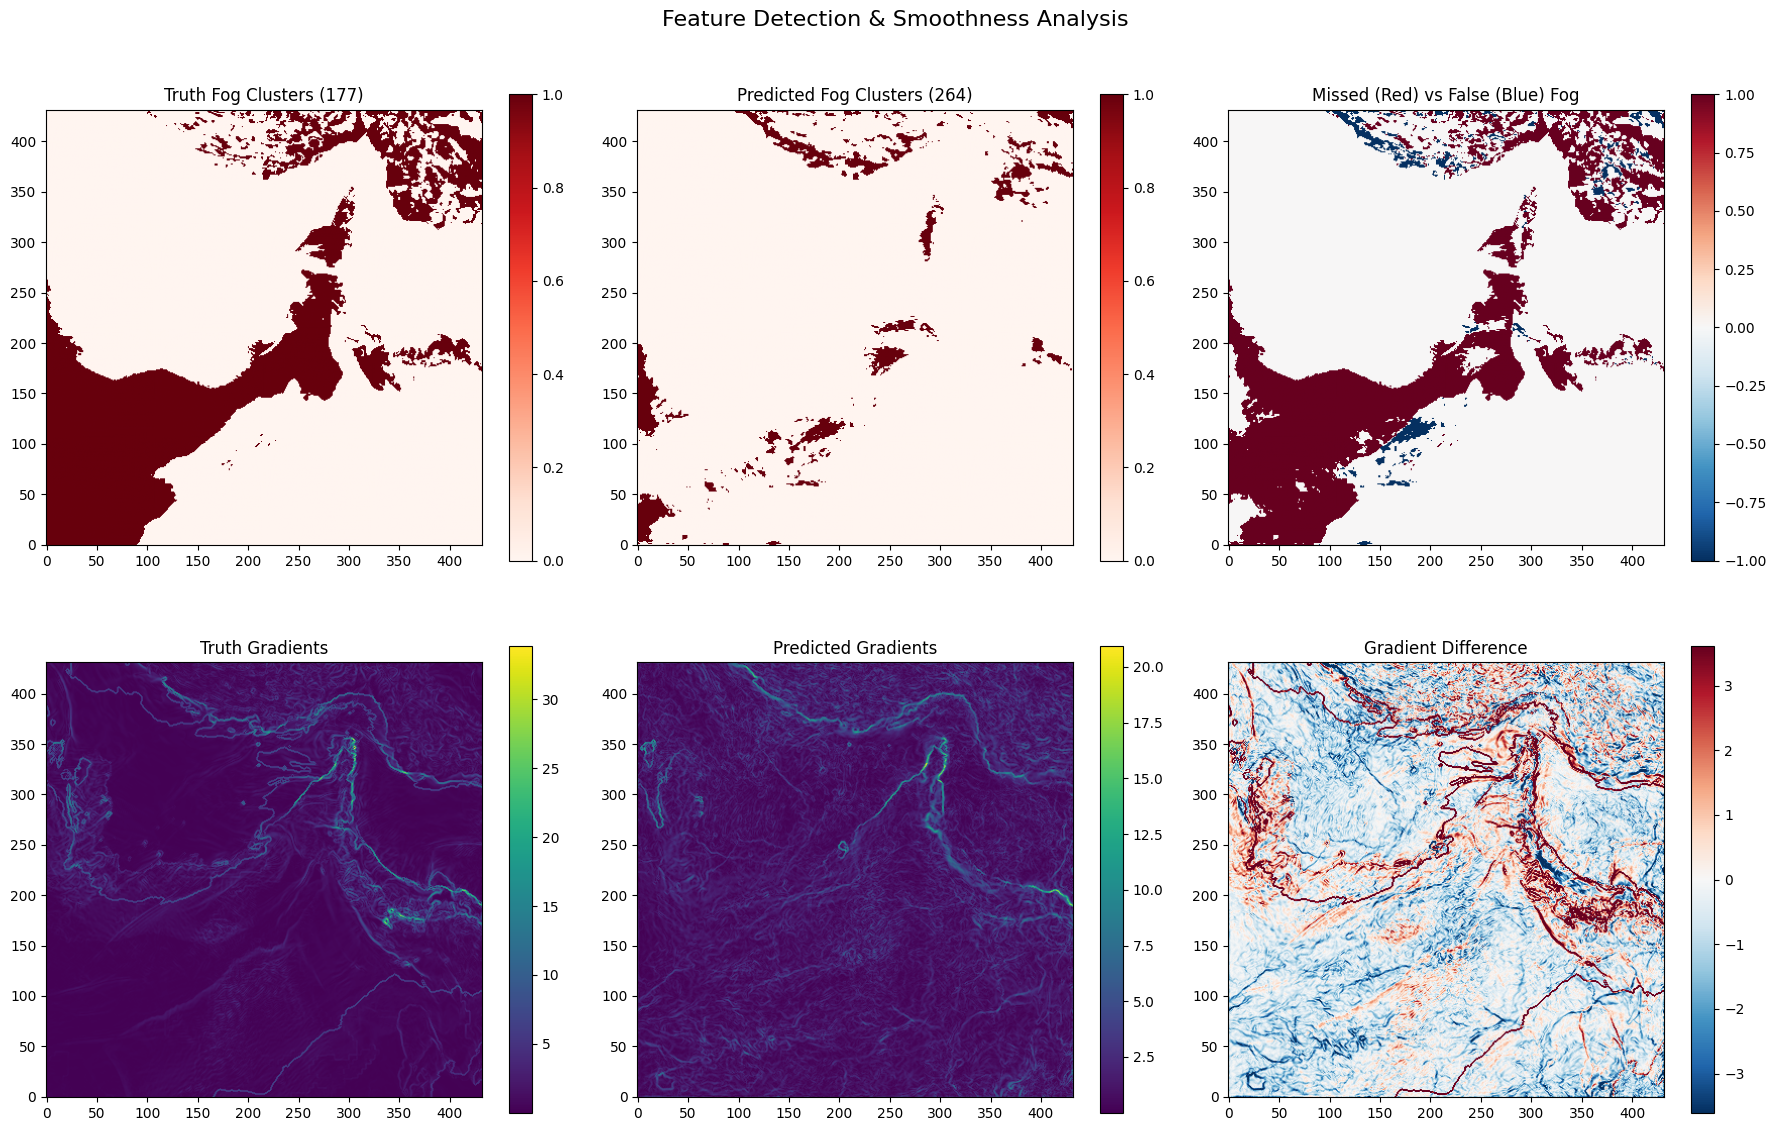

In [11]:
# Visualize feature detection
if coords_2d:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': proj})
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Fog clusters
fog_data = [truth_fog_mask, pred_fog_mask, truth_fog_mask.astype(int) - pred_fog_mask.astype(int)]
fog_titles = [f'Truth Fog Clusters ({n_truth_clusters})', f'Predicted Fog Clusters ({n_pred_clusters})', 'Missed (Red) vs False (Blue) Fog']
fog_cmaps = ['Reds', 'Reds', 'RdBu_r']

for i, (data, title, cmap) in enumerate(zip(fog_data, fog_titles, fog_cmaps)):
    ax = axes[0, i]
    if coords_2d:
        ax.add_feature(cfeature.COASTLINE, alpha=0.7)
        im = ax.pcolormesh(lon_2d, lat_2d, data, transform=proj, cmap=cmap)
    else:
        im = ax.imshow(data, cmap=cmap, origin='lower')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Row 2: Gradients and smoothness
grad_data = [truth_gradients, pred_gradients, truth_gradients - pred_gradients]
grad_titles = ['Truth Gradients', 'Predicted Gradients', 'Gradient Difference']
grad_cmaps = ['viridis', 'viridis', 'RdBu_r']

for i, (data, title, cmap) in enumerate(zip(grad_data, grad_titles, grad_cmaps)):
    ax = axes[1, i]
    if coords_2d:
        ax.add_feature(cfeature.COASTLINE, alpha=0.7)
        if i == 2:
            vmax_grad = np.percentile(np.abs(data), 95)
            im = ax.pcolormesh(lon_2d, lat_2d, data, transform=proj, cmap=cmap, vmin=-vmax_grad, vmax=vmax_grad)
        else:
            im = ax.pcolormesh(lon_2d, lat_2d, data, transform=proj, cmap=cmap)
    else:
        if i == 2:
            vmax_grad = np.percentile(np.abs(data), 95)
            im = ax.imshow(data, cmap=cmap, vmin=-vmax_grad, vmax=vmax_grad, origin='lower')
        else:
            im = ax.imshow(data, cmap=cmap, origin='lower')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Feature Detection & Smoothness Analysis', fontsize=16)
plt.tight_layout()
plt.show()

# 4️⃣ Diffusion Parameters Assessment

**Goal**: Evaluate if 20 diffusion steps are optimal or causing issues

In [12]:
# Diffusion parameters analysis
current_steps = 20
current_sampling = 'stochastic'

print(f'🎛️ DIFFUSION PARAMETERS ASSESSMENT:')
print(f'   Current configuration: {current_steps} steps, {current_sampling} sampling')
print(f'   Current R²: {best_r2:.4f}')

# Scoring system for issues
scores = {'over_smooth': 0, 'cluster_loss': 0, 'poor_r2': 0}

# Over-smoothing score
if smoothness_ratio < 0.3:
    scores['over_smooth'] = 3
    print('   🚨 Severe over-smoothing detected')
elif smoothness_ratio < 0.7:
    scores['over_smooth'] = 2
    print('   ⚠️ Moderate over-smoothing detected')
elif smoothness_ratio > 2.0:
    scores['over_smooth'] = 1
    print('   ⚠️ Under-smoothing detected')
else:
    print('   ✅ Smoothness levels reasonable')

# Cluster loss score
if n_truth_clusters > 0:
    cluster_ratio = n_pred_clusters / n_truth_clusters
    if cluster_ratio < 0.3:
        scores['cluster_loss'] = 3
        print('   🚨 Severe cluster loss detected')
    elif cluster_ratio < 0.7:
        scores['cluster_loss'] = 2
        print('   ⚠️ Moderate cluster loss detected')
    else:
        print('   ✅ Cluster detection reasonable')

# R² performance score
if best_r2 < 0.0:
    scores['poor_r2'] = 3
    print('   🚨 Very poor R² performance')
elif best_r2 < 0.3:
    scores['poor_r2'] = 2
    print('   ⚠️ Poor R² performance')
elif best_r2 < 0.7:
    scores['poor_r2'] = 1
    print('   ⚠️ Moderate R² performance')
else:
    print('   ✅ Good R² performance')

total_score = sum(scores.values())
print(f'\n📊 Issue scores: Over-smooth: {scores["over_smooth"]}, Cluster loss: {scores["cluster_loss"]}, Poor R²: {scores["poor_r2"]} (Total: {total_score}/9)')

🎛️ DIFFUSION PARAMETERS ASSESSMENT:
   Current configuration: 20 steps, stochastic sampling
   Current R²: 0.7849
   ✅ Smoothness levels reasonable
   ✅ Cluster detection reasonable
   ✅ Good R² performance

📊 Issue scores: Over-smooth: 0, Cluster loss: 0, Poor R²: 0 (Total: 0/9)


# 5️⃣ Summary & Recommendations

**Goal**: Provide actionable insights and specific parameter recommendations

In [13]:
print('🎯' * 50)
print('COMPREHENSIVE ANALYSIS SUMMARY')
print('🎯' * 50)

print(f'\n📊 KEY FINDINGS:')
print(f'   🏆 Best scaling approach: {scenario_names[best_scenario]}')
print(f'   📈 Best R² achieved: {best_r2:.4f}')
print(f'   🌫️ Fog cluster detection: {n_pred_clusters}/{n_truth_clusters} ({100*n_pred_clusters/max(n_truth_clusters,1):.1f}%)')
print(f'   📐 Smoothness ratio: {smoothness_ratio:.3f} ({"over-smooth" if smoothness_ratio < 0.7 else "under-smooth" if smoothness_ratio > 1.5 else "reasonable"})')

print(f'\n🔧 PRIORITY RECOMMENDATIONS:')

# Priority 1: Data scaling fix
if best_scenario != 'raw':
    print('1. 🚨 DATA SCALING ISSUE (HIGH PRIORITY)')
    if best_scenario == 'truth_norm':
        print('   💡 Earth2Studio outputs denormalized predictions, but ground truth is normalized')
        print('   🔧 FIX: Modify output.py to denormalize ground truth before saving')
        print('   🔧 OR: Modify metrics to normalize predictions before comparison')
    elif best_scenario == 'pred_norm':
        print('   💡 Predictions need normalization for proper comparison')
        print('   🔧 FIX: Normalize predictions in visualization pipeline')
    else:
        print(f'   🔧 FIX: Use {best_scenario} scaling consistently throughout pipeline')
else:
    print('1. ✅ DATA SCALING: No issues detected')

# Priority 2: Diffusion parameter tuning
if total_score >= 5:
    print('\n2. 🚨 DIFFUSION PARAMETERS (HIGH PRIORITY)')
    if scores['over_smooth'] >= 2:
        print(f'   📉 Current {current_steps} steps causing over-smoothing')
        print('   🔧 TRY: Reduce to 5-10 steps')
        print('   🔧 TRY: Switch to deterministic sampling')
    if scores['cluster_loss'] >= 2:
        print('   🌫️ Model failing to detect fog clusters')
        print('   🔧 TRY: Lower diffusion steps (1-5)')
        print('   🔧 TRY: Different solver (heun vs euler)')
elif total_score >= 2:
    print('\n2. ⚠️ DIFFUSION PARAMETERS (MEDIUM PRIORITY)')
    print('   🔧 Fine-tune: Try 10-15 steps instead of 20')
else:
    print('\n2. ✅ DIFFUSION PARAMETERS: Appear reasonable')

# Priority 3: Performance optimization
if best_r2 > 0.5:
    print('\n3. ✅ MODEL PERFORMANCE: Good - focus on fine-tuning')
elif best_r2 > 0.0:
    print('\n3. ⚠️ MODEL PERFORMANCE: Moderate - investigate training data')
else:
    print('\n3. 🚨 MODEL PERFORMANCE: Poor - check model architecture/training')

print(f'\n📋 IMPLEMENTATION CHECKLIST:')
print('   □ Fix data scaling in output pipeline')
if total_score >= 2:
    print('   □ Experiment with diffusion steps: [1, 5, 10, 15]')
    print('   □ Test deterministic vs stochastic sampling')
print('   □ Validate on multiple time indices')
print('   □ Monitor R² improvement after fixes')

print(f'\n✨ EXPECTED IMPROVEMENT:')
if best_scenario != 'raw' and best_r2 > 0.3:
    print(f'   🎯 Data scaling fix should significantly improve metrics')
if scores['over_smooth'] >= 2:
    print(f'   🎯 Reducing diffusion steps should preserve fog clusters better')
if best_r2 < 0.0:
    print(f'   🎯 Focus on data scaling first, then diffusion parameters')

print('\n🚀 Ready to implement improvements!')

🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯
COMPREHENSIVE ANALYSIS SUMMARY
🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

📊 KEY FINDINGS:
   🏆 Best scaling approach: 🔵 Raw
   📈 Best R² achieved: 0.7849
   🌫️ Fog cluster detection: 264/177 (149.2%)
   📐 Smoothness ratio: 1.125 (reasonable)

🔧 PRIORITY RECOMMENDATIONS:
1. ✅ DATA SCALING: No issues detected

2. ✅ DIFFUSION PARAMETERS: Appear reasonable

3. ✅ MODEL PERFORMANCE: Good - focus on fine-tuning

📋 IMPLEMENTATION CHECKLIST:
   □ Fix data scaling in output pipeline
   □ Validate on multiple time indices
   □ Monitor R² improvement after fixes

✨ EXPECTED IMPROVEMENT:

🚀 Ready to implement improvements!


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


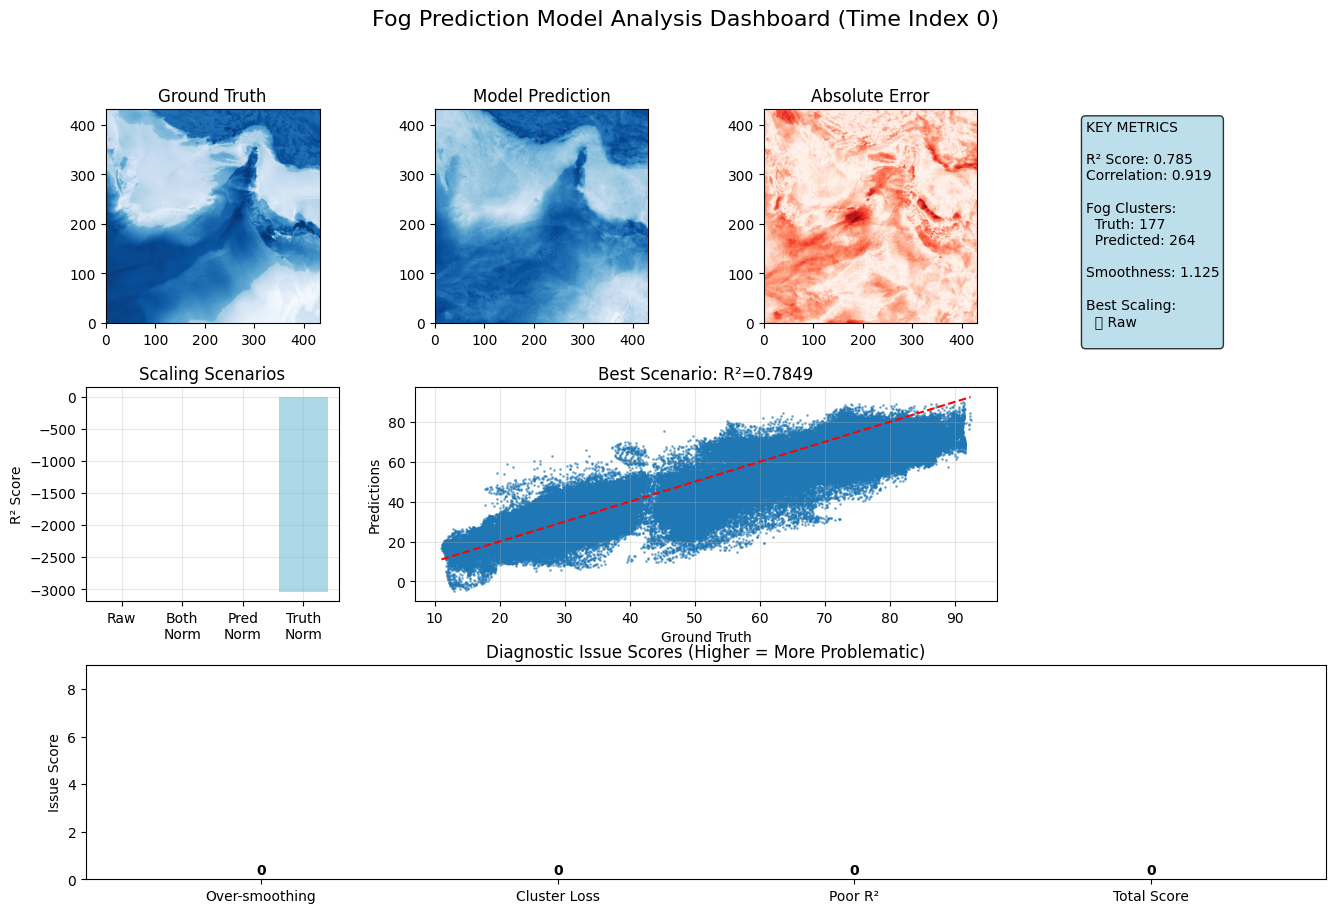

In [14]:
# Create summary dashboard
fig = plt.figure(figsize=(16, 10))

# Create custom layout
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Top row: Main comparison
if coords_2d:
    ax1 = fig.add_subplot(gs[0, 0], projection=proj)
    ax2 = fig.add_subplot(gs[0, 1], projection=proj)
    ax3 = fig.add_subplot(gs[0, 2], projection=proj)
else:
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

# Plot spatial truth, prediction, error
if coords_2d:
    for ax in [ax1, ax2, ax3]:
        ax.add_feature(cfeature.COASTLINE, alpha=0.7)
    im1 = ax1.pcolormesh(lon_2d, lat_2d, spatial_truth, transform=proj, cmap='Blues')
    im2 = ax2.pcolormesh(lon_2d, lat_2d, spatial_pred, transform=proj, cmap='Blues')
    im3 = ax3.pcolormesh(lon_2d, lat_2d, spatial_abs_error, transform=proj, cmap='Reds')
else:
    im1 = ax1.imshow(spatial_truth, cmap='Blues', origin='lower')
    im2 = ax2.imshow(spatial_pred, cmap='Blues', origin='lower')
    im3 = ax3.imshow(spatial_abs_error, cmap='Reds', origin='lower')

ax1.set_title('Ground Truth')
ax2.set_title('Model Prediction')
ax3.set_title('Absolute Error')

# Middle row: Metrics and analysis
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1:3])
ax6 = fig.add_subplot(gs[0, 3])

# R² comparison
r2_values = [valid_scenarios[k]['r2'] for k in ['raw', 'both_norm', 'pred_norm', 'truth_norm']]
r2_labels = ['Raw', 'Both\nNorm', 'Pred\nNorm', 'Truth\nNorm']
colors = ['gold' if k == best_scenario else 'lightblue' for k in ['raw', 'both_norm', 'pred_norm', 'truth_norm']]
ax4.bar(r2_labels, r2_values, color=colors)
ax4.set_ylabel('R² Score')
ax4.set_title('Scaling Scenarios')
ax4.grid(True, alpha=0.3)

# Scatter plot
best_data = valid_scenarios[best_scenario]
ax5.scatter(best_data['truth'], best_data['pred'], alpha=0.5, s=1)
min_val = best_data['truth'].min()
max_val = max(best_data['truth'].max(), best_data['pred'].max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--')
ax5.set_xlabel('Ground Truth')
ax5.set_ylabel('Predictions')
ax5.set_title(f'Best Scenario: R²={best_r2:.4f}')
ax5.grid(True, alpha=0.3)

# Summary metrics
ax6.axis('off')
summary_text = f'''KEY METRICS

R² Score: {best_r2:.3f}
Correlation: {valid_scenarios[best_scenario]["corr"]:.3f}

Fog Clusters:
  Truth: {n_truth_clusters}
  Predicted: {n_pred_clusters}

Smoothness: {smoothness_ratio:.3f}

Best Scaling:
  {scenario_names[best_scenario]}
'''
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Bottom row: Issue scores
ax7 = fig.add_subplot(gs[2, :])
issues = ['Over-smoothing', 'Cluster Loss', 'Poor R²', 'Total Score']
issue_scores = [scores['over_smooth'], scores['cluster_loss'], scores['poor_r2'], total_score]
colors = ['red' if s >= 2 else 'orange' if s >= 1 else 'green' for s in issue_scores[:-1]] + ['purple']
bars = ax7.bar(issues, issue_scores, color=colors)
ax7.set_ylabel('Issue Score')
ax7.set_title('Diagnostic Issue Scores (Higher = More Problematic)')
ax7.set_ylim(0, max(9, max(issue_scores) + 1))
for bar, score in zip(bars, issue_scores):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(score), 
             ha='center', va='bottom', fontweight='bold')

plt.suptitle(f'Fog Prediction Model Analysis Dashboard (Time Index {time_idx})', fontsize=16)
plt.show()